# FP8 (TransformerEngine) vs BF16 — training-time benchmark

How much faster does the **TransformerEngine FP8** BatchTopK SAE train than the **BF16** recipe
(fp32 master + bf16 autocast), and **where does the time go**? Measured on `gemma` (d_in=2304),
width `65536`, MI300X.

Two complementary views (run the scripts first):

```bash
# Part A — SAE-step microbench (synthetic activations) + torch.profiler op breakdown
python experiments/bench_te_vs_bf16_train_time.py --part micro --model gemma --width 65536 --ks 20,160,640

# Part B — end-to-end real trainer, steady-state tokens/s over a short (2.5M-token) run
python experiments/bench_te_vs_bf16_realtrain.py --model gemma --width 65536 --k 160 --tokens 2500000
```

- **Part A (SAE compute only):** isolates the encoder/decoder GEMMs — exactly the part FP8 changes —
  by timing `encode + BatchTopK + decode + loss + backward + optimizer` on synthetic acts.
- **Part B (end-to-end):** includes the precision-independent **LLM forward** that generates the
  activations, so it shows the *realized* speedup during real training (the SAE-step gain, diluted).

Both measure a short run and **project linearly to 100M tokens**.

In [13]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

BENCH = Path("/wekafs/smerrill/efficient_sae/experiments/results/bench_te_vs_bf16")
MODEL, WIDTH = "gemma", 65536

micro = json.loads((BENCH / f"micro_{MODEL}_w{WIDTH}.json").read_text())
real = json.loads((BENCH / f"realtrain_{MODEL}_w{WIDTH}.json").read_text())

print("device      :", micro["meta"]["device"])
print("model/width :", MODEL, WIDTH, "| batch:", micro["meta"]["batch"], "tokens/step")
print("micro ks    :", list(micro["by_k"]))
print("TE recipe   :", micro["meta"]["recipe"], "/", micro["meta"]["scaling"])

# representative k for the single-point views (middle of the swept ks)
ks = list(micro["by_k"])
K_REP = "160" if "160" in ks else ks[len(ks) // 2]

# --- Part A: per-k SAE-step table ---
rows = []
for k, d in micro["by_k"].items():
    rows.append(dict(
        k=int(k),
        bf16_ms=d["bf16"]["ms_per_step_median"],
        fp8te_ms=d["fp8te"]["ms_per_step_median"],
        speedup=d["speedup_bf16_over_fp8te"],
        bf16_h_100M=d["bf16"]["projection"]["hours_for_100M"],
        fp8te_h_100M=d["fp8te"]["projection"]["hours_for_100M"],
        bf16_GB=d["bf16"]["peak_mem_gb"],
        fp8te_GB=d["fp8te"]["peak_mem_gb"],
    ))
partA = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)
partA

device      : AMD Instinct MI300X
model/width : gemma 65536 | batch: 2048 tokens/step
micro ks    : ['20', '160', '640']
TE recipe   : hybrid / delayed


,k,bf16_ms,fp8te_ms,speedup,bf16_h_100M,fp8te_h_100M,bf16_GB,fp8te_GB
0,20,31.529233,28.045676,1.124210,0.427643,0.380394,10.046937,10.085346
1,160,32.188368,28.366755,1.134722,0.436583,0.384749,10.085350,10.089057
2,640,32.547523,28.590820,1.138391,0.441454,0.387788,10.095745,10.100600


In [14]:
# --- Part B: end-to-end steady-state table ---
rb = real["recipes"]
partB = pd.DataFrame([
    dict(recipe="BF16",
         tok_per_s=rb["bf16"]["tokens_per_s_steady_median"],
         h_100M=rb["bf16"]["hours_for_100M"]),
    dict(recipe="FP8-TE",
         tok_per_s=rb["fp8te"]["tokens_per_s_steady_median"],
         h_100M=rb["fp8te"]["hours_for_100M"]),
])

sae_speedup = partA.loc[partA["k"] == int(K_REP), "speedup"].iloc[0]
e2e_speedup = real.get("end2end_speedup_fp8te_over_bf16", float("nan"))

print(f"SAE-step speedup  (Part A, k={K_REP}) : {sae_speedup:.3f}x  FP8-TE faster")
print(f"end-to-end speedup (Part B)          : {e2e_speedup:.3f}x  FP8-TE faster")
print(f"  BF16   end-to-end: {rb['bf16']['tokens_per_s_steady_median']:,.0f} tok/s "
      f"-> {rb['bf16']['hours_for_100M']:.2f} h / 100M")
print(f"  FP8-TE end-to-end: {rb['fp8te']['tokens_per_s_steady_median']:,.0f} tok/s "
      f"-> {rb['fp8te']['hours_for_100M']:.2f} h / 100M")
partB

SAE-step speedup  (Part A, k=160) : 1.135x  FP8-TE faster
end-to-end speedup (Part B)          : 1.091x  FP8-TE faster
  BF16   end-to-end: 32,248 tok/s -> 0.86 h / 100M
  FP8-TE end-to-end: 35,167 tok/s -> 0.79 h / 100M


,recipe,tok_per_s,h_100M
0,BF16,32247.77,0.861386
1,FP8-TE,35167.32,0.789875


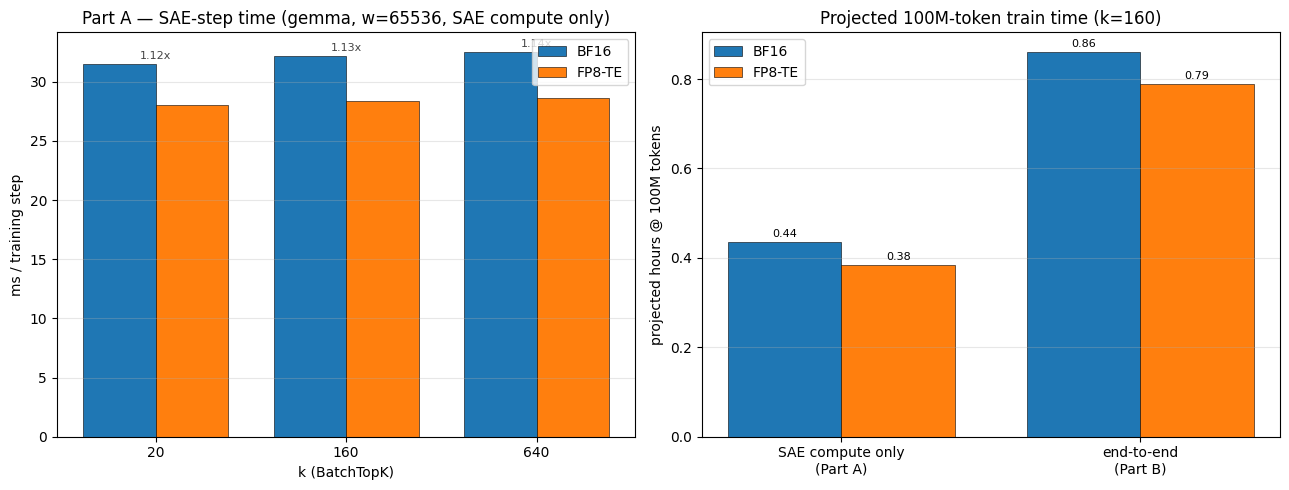

In [15]:
# --- SAE-step time vs k (Part A), and headline 100M projection (Part A vs Part B) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# left: ms/step vs k
idx = partA["k"].astype(str)
w = 0.38
xs = range(len(idx))
ax1.bar([x - w / 2 for x in xs], partA["bf16_ms"], w, label="BF16", edgecolor="black", linewidth=0.4)
ax1.bar([x + w / 2 for x in xs], partA["fp8te_ms"], w, label="FP8-TE", edgecolor="black", linewidth=0.4)
ax1.set_xticks(list(xs)); ax1.set_xticklabels(idx)
ax1.set_xlabel("k (BatchTopK)"); ax1.set_ylabel("ms / training step")
ax1.set_title(f"Part A — SAE-step time ({MODEL}, w={WIDTH}, SAE compute only)")
ax1.grid(axis="y", alpha=0.3); ax1.legend()
for i, r in partA.iterrows():
    ax1.text(i, max(r["bf16_ms"], r["fp8te_ms"]) + 0.4, f"{r['speedup']:.2f}x",
             ha="center", fontsize=8, color="#444")

# right: projected hours to 100M — SAE-only (k=K_REP) vs end-to-end
a = partA.loc[partA["k"] == int(K_REP)].iloc[0]
scen = ["SAE compute only\n(Part A)", "end-to-end\n(Part B)"]
bf16_h = [a["bf16_h_100M"], rb["bf16"]["hours_for_100M"]]
fp8_h = [a["fp8te_h_100M"], rb["fp8te"]["hours_for_100M"]]
xs2 = range(len(scen))
b1 = ax2.bar([x - w / 2 for x in xs2], bf16_h, w, label="BF16", edgecolor="black", linewidth=0.4)
b2 = ax2.bar([x + w / 2 for x in xs2], fp8_h, w, label="FP8-TE", edgecolor="black", linewidth=0.4)
ax2.set_xticks(list(xs2)); ax2.set_xticklabels(scen)
ax2.set_ylabel("projected hours @ 100M tokens")
ax2.set_title(f"Projected 100M-token train time (k={K_REP})")
ax2.grid(axis="y", alpha=0.3); ax2.legend()
ax2.bar_label(b1, fmt="%.2f", padding=2, fontsize=8)
ax2.bar_label(b2, fmt="%.2f", padding=2, fontsize=8)

plt.tight_layout(); plt.show()

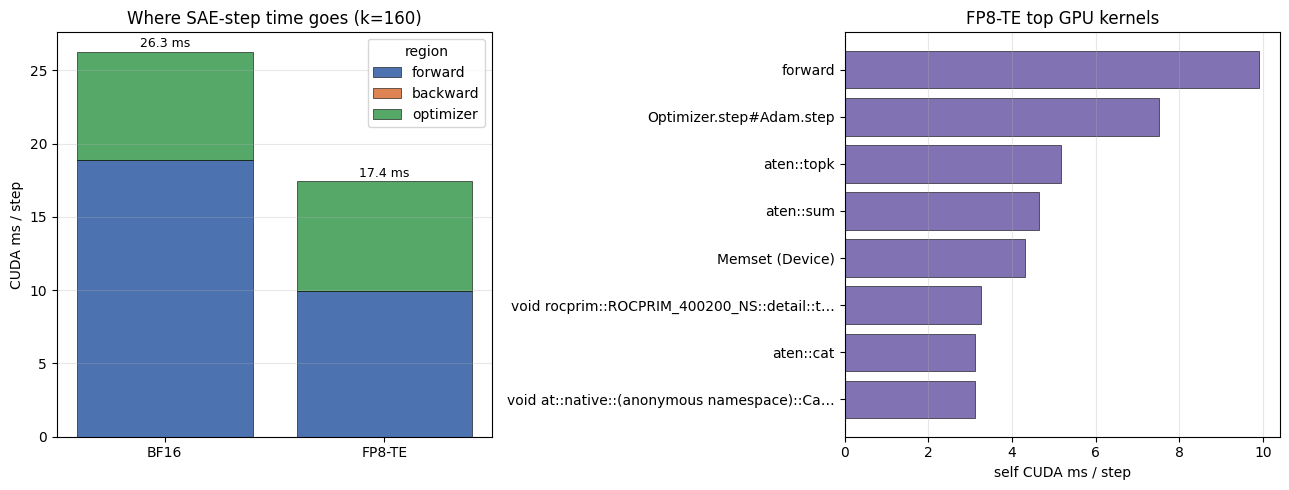

Top FP8-TE kernels (self CUDA ms/step):
     9.91 ms  x4     forward
     7.53 ms  x5     Optimizer.step#Adam.step
     5.18 ms  x5     aten::topk
     4.64 ms  x20    aten::sum
     4.31 ms  x53    Memset (Device)
     3.25 ms  x12    void rocprim::ROCPRIM_400200_NS::detail::trampoline_kernel<rocprim::ROCPRIM_4002
     3.11 ms  x20    aten::cat
     3.11 ms  x18    void at::native::(anonymous namespace)::CatArrayBatchedCopy_contig<at::native::(


In [16]:
# --- Where the SAE-step time goes (Part A torch.profiler, k=K_REP) ---
# region_cuda_us totals are summed over the profiler's 5 active steps -> per-step ms.
ACTIVE_STEPS = 5
prof = {r: micro["by_k"][K_REP][r]["profile"] for r in ("bf16", "fp8te")}
regions = ["forward", "backward", "optimizer"]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# left: stacked per-step ms by region
bottom = {r: 0.0 for r in ("bf16", "fp8te")}
colors = {"forward": "#4C72B0", "backward": "#DD8452", "optimizer": "#55A868"}
labels = {"bf16": "BF16", "fp8te": "FP8-TE"}
for reg in regions:
    vals = [prof[r]["region_cuda_us"].get(reg, 0.0) / ACTIVE_STEPS / 1e3 for r in ("bf16", "fp8te")]
    axL.bar(["BF16", "FP8-TE"], vals, bottom=[bottom["bf16"], bottom["fp8te"]],
            label=reg, color=colors[reg], edgecolor="black", linewidth=0.4)
    bottom["bf16"] += vals[0]; bottom["fp8te"] += vals[1]
axL.set_ylabel("CUDA ms / step"); axL.set_title(f"Where SAE-step time goes (k={K_REP})")
axL.grid(axis="y", alpha=0.3); axL.legend(title="region")
for i, r in enumerate(("bf16", "fp8te")):
    axL.text(i, bottom[r] + 0.3, f"{bottom[r]:.1f} ms", ha="center", fontsize=9)

# right: top GPU kernels (self CUDA ms/step) for FP8-TE
te_ops = prof["fp8te"]["top_ops"][:8]
names = [o["op"][:42] + ("…" if len(o["op"]) > 42 else "") for o in te_ops][::-1]
usec = [o["self_cuda_us"] / ACTIVE_STEPS / 1e3 for o in te_ops][::-1]
axR.barh(names, usec, color="#8172B3", edgecolor="black", linewidth=0.4)
axR.set_xlabel("self CUDA ms / step"); axR.set_title("FP8-TE top GPU kernels")
axR.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

print("Top FP8-TE kernels (self CUDA ms/step):")
for o in te_ops:
    print(f"  {o['self_cuda_us']/ACTIVE_STEPS/1e3:7.2f} ms  x{o['count']:<4d}  {o['op'][:80]}")